# f8 RDF descriptors → PCA & how many components to keep

Group **f8_surface_shape_RDF** uses Dragon columns whose names start with **`RDF`** (radial distribution descriptors; ~209 in your matrix).

Same workflow as `f7_mor_dimension_explore.ipynb`: **standardize → PCA → cumulative variance plot** so you can see how many PCs you need (e.g. for ~80% variance).

**Data:** `data/waka_dragon_merged.csv`

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

csv_path = Path("data/waka_dragon_merged.csv")
if not csv_path.is_file():
    raise FileNotFoundError(f"Put merged CSV here: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
print("rows, cols:", df.shape)

rows, cols: (312, 2499)


### Step 1 — Keep only RDF columns

Same rule as `features_set_1.ipynb`: names starting with **`RDF`**.

In [2]:
block_cols = [c for c in df.columns if c.startswith("RDF")]
print("number of RDF descriptors:", len(block_cols))

X = df[block_cols].apply(pd.to_numeric, errors="coerce")
X = X.dropna(how="all")
print("samples after dropna(all):", len(X))

number of RDF descriptors: 209
samples after dropna(all): 288


### Step 2 — Standardize

In [3]:
X_filled = X.fillna(X.median(numeric_only=True))
scaler = StandardScaler()
Xz = scaler.fit_transform(X_filled)
print("scaled matrix shape:", Xz.shape)

scaled matrix shape: (288, 209)


### Step 3 — Cumulative variance (how many PCs?)

The dashed line is **80%** cumulative variance — a common *heuristic* for “how many PCs represent most of this block.” Your modeling choice can be fewer (simpler) or match this k (more faithful to variance).

Smallest k with cumulative variance >= 80%: k80 = 7


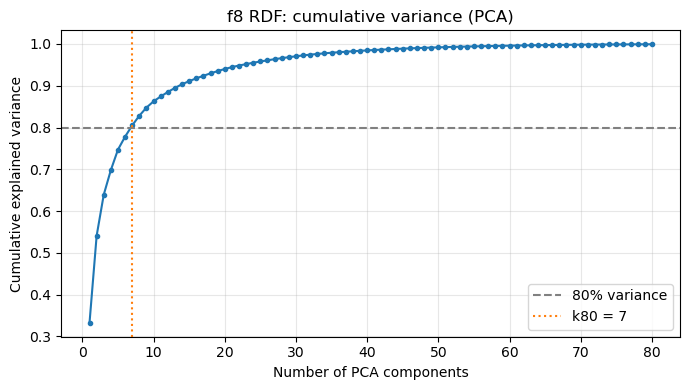

First 1 PC(s): 33.2% variance
First 2 PC(s): 54.1% variance
First 3 PC(s): 63.9% variance
First 5 PC(s): 74.7% variance
First 10 PC(s): 86.3% variance
First k80=7 PC(s): 80.5% variance


In [4]:
n_samples, n_features = Xz.shape
n_pca = min(80, n_samples - 1, n_features)

pca_explore = PCA(n_components=n_pca, random_state=0)
pca_explore.fit(Xz)

var_ratio = pca_explore.explained_variance_ratio_
cumsum = var_ratio.cumsum()

k80 = next((i + 1 for i, v in enumerate(cumsum) if v >= 0.8), len(cumsum))
print(f"Smallest k with cumulative variance >= 80%: k80 = {k80}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumsum) + 1), cumsum, marker="o", markersize=3)
ax.axhline(0.8, color="gray", linestyle="--", label="80% variance")
if k80 <= len(cumsum):
    ax.axvline(k80, color="C1", linestyle=":", label=f"k80 = {k80}")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("f8 RDF: cumulative variance (PCA)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k in (1, 2, 3, 5, 10):
    if k <= len(cumsum):
        print(f"First {k} PC(s): {cumsum[k-1]*100:.1f}% variance")
print(f"First k80={k80} PC(s): {cumsum[k80-1]*100:.1f}% variance")

### Step 4 — Export PCA scores as features

Set **`n_keep`** to the number of PCs you want in your model (e.g. **`k80`** from Step 3, or a smaller number for a simpler model).

In [5]:
# Change this: use k80 for ~80% variance in this block, or e.g. 3–7 for fewer columns
n_keep = k80

pca_scores = PCA(n_components=n_keep, random_state=0)
scores = pca_scores.fit_transform(Xz)

out = pd.DataFrame(
    scores,
    columns=[f"RDF_PC{i+1}" for i in range(n_keep)],
    index=X.index,
)
if "CID" in df.columns:
    out.insert(0, "CID", df.loc[X.index, "CID"].values)

out.head()

,CID,RDF_PC1,RDF_PC2,RDF_PC3,RDF_PC4,RDF_PC5,RDF_PC6,RDF_PC7
0,179,-12.594660,0.747199,-0.414432,-0.170574,0.238991,0.226288,0.709589
1,240,-13.504221,0.969243,-0.790421,0.188446,-0.090784,0.960680,0.384733
2,244,-11.609964,0.560985,-0.481136,0.006984,-0.188568,0.473781,0.454376
3,323,-11.464245,-0.195995,-0.102267,-0.335778,0.762428,0.982593,0.771412
4,326,-6.494218,-1.045439,0.447670,-0.057647,-0.249542,0.610829,-0.714801


### Step 5 (optional) — Top loadings on RDF_PC1

In [6]:
loadings = pd.DataFrame(
    pca_scores.components_.T,
    index=block_cols,
    columns=[f"RDF_PC{i+1}" for i in range(n_keep)],
)
col1 = loadings.columns[0]
top = loadings[col1].abs().sort_values(ascending=False).head(15)
print(f"Top 15 |loading| on {col1}:")
print(loadings.loc[top.index, col1])

Top 15 |loading| on RDF_PC1:
RDF010p    0.111383
RDF010v    0.111084
RDF010u    0.110337
RDF015s    0.109935
RDF010i    0.109557
RDF010m    0.109522
RDF010e    0.109124
RDF015i    0.107658
RDF015e    0.107636
RDF015m    0.107494
RDF015u    0.107323
RDF015v    0.106486
RDF065i    0.105793
RDF015p    0.105579
RDF065e    0.105308
Name: RDF_PC1, dtype: float64


**Recap:** `k80` estimates how many PCs you need for ~80% variance **within the RDF block**. For a full model with many other descriptor groups, you might keep fewer RDF PCs and rely on cross-validation.